In [1]:
!pip install gymnasium
!pip install tensorflow
!pip install keras
!pip install numpy
!pip install matplotlib

In [1]:
import gymnasium as gym
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("Gymnasium Version:", gym.__version__)
print("NumPy Version:", np.__version__)
print("TensorFlow Version:", tf.__version__)

env = gym.make("CartPole-v1")

state, info = env.reset()

print("Initial State:")
print(state)

env.close()

Gymnasium Version: 1.3.0
NumPy Version: 2.1.3
TensorFlow Version: 2.21.0
Initial State:
[-0.03141207 -0.00507137  0.0238487   0.01159838]


In [2]:
import gymnasium as gym

# Create FrozenLake environment
env = gym.make("FrozenLake-v1", render_mode="ansi")

# Reset environment
state, info = env.reset()

print("Initial State:", state)

done = False
step = 1

while not done:
    action = env.action_space.sample()   # Random action

    next_state, reward, terminated, truncated, info = env.step(action)

    print(f"Step {step}")
    print("Action:", action)
    print("Next State:", next_state)
    print("Reward:", reward)

    state = next_state
    step += 1

    done = terminated or truncated

env.close()

Initial State: 0
Step 1
Action: 0
Next State: 4
Reward: 0
Step 2
Action: 2
Next State: 5
Reward: 0


In [3]:
import gymnasium as gym

# Create CartPole environment
env = gym.make("CartPole-v1")

# Reset environment
state, info = env.reset()

total_reward = 0
done = False
step = 1

while not done:
    action = env.action_space.sample()   # Random policy

    next_state, reward, terminated, truncated, info = env.step(action)

    print(f"Step {step}")
    print("Current State :", state)
    print("Action Taken  :", action)
    print("Reward        :", reward)
    print("Next State    :", next_state)
    print()

    state = next_state
    total_reward += reward
    step += 1

    done = terminated or truncated

print("Total Reward:", total_reward)

env.close()

Step 1
Current State : [-0.00408616 -0.0344849   0.0387633   0.01890184]
Action Taken  : 1
Reward        : 1.0
Next State    : [-0.00477585  0.16006032  0.03914133 -0.26130322]

Step 2
Current State : [-0.00477585  0.16006032  0.03914133 -0.26130322]
Action Taken  : 0
Reward        : 1.0
Next State    : [-0.00157465 -0.03559787  0.03391527  0.0434639 ]

Step 3
Current State : [-0.00157465 -0.03559787  0.03391527  0.0434639 ]
Action Taken  : 1
Reward        : 1.0
Next State    : [-0.00228661  0.15902175  0.03478455 -0.23832847]

Step 4
Current State : [-0.00228661  0.15902175  0.03478455 -0.23832847]
Action Taken  : 1
Reward        : 1.0
Next State    : [ 0.00089383  0.35362995  0.03001798 -0.5198396 ]

Step 5
Current State : [ 0.00089383  0.35362995  0.03001798 -0.5198396 ]
Action Taken  : 0
Reward        : 1.0
Next State    : [ 0.00796643  0.15809855  0.01962119 -0.21785067]

Step 6
Current State : [ 0.00796643  0.15809855  0.01962119 -0.21785067]
Action Taken  : 1
Reward        : 1.0

In [4]:
# Simple Markov Decision Process (MDP)

states = ["A", "B", "C", "Goal"]

transitions = {
    "A": ("B", 5),
    "B": ("C", 10),
    "C": ("Goal", 20)
}

current_state = "A"
total_reward = 0

print("Starting State:", current_state)

while current_state != "Goal":
    next_state, reward = transitions[current_state]

    print(f"{current_state} --> {next_state} | Reward = {reward}")

    total_reward += reward
    current_state = next_state

print("\nGoal Reached!")
print("Total Reward:", total_reward)

Starting State: A
A --> B | Reward = 5
B --> C | Reward = 10
C --> Goal | Reward = 20

Goal Reached!
Total Reward: 35


In [5]:
# Bellman Equation Demonstration

gamma = 0.9

# Rewards for each state
rewards = [5, 10, 20]

# Initialize state values
values = [0, 0, 0]

print("Initial State Values:", values)

# Perform Bellman updates
for i in range(10):
    values[2] = rewards[2]
    values[1] = rewards[1] + gamma * values[2]
    values[0] = rewards[0] + gamma * values[1]

print("\nFinal State Values:")

for i in range(3):
    print(f"State {i+1}: {values[i]:.2f}")

Initial State Values: [0, 0, 0]

Final State Values:
State 1: 30.20
State 2: 28.00
State 3: 20.00


In [6]:
import numpy as np

# Estimated rewards for actions
action_values = [10, 25, 15, 30]

print("Estimated Rewards:", action_values)

# Greedy Strategy
greedy_action = np.argmax(action_values)
print("\nGreedy Strategy")
print("Selected Action:", greedy_action)

# ε-Greedy Strategy
epsilon = 0.2

if np.random.rand() < epsilon:
    epsilon_action = np.random.randint(len(action_values))
    print("\nε-Greedy Strategy")
    print("Exploration")
else:
    epsilon_action = np.argmax(action_values)
    print("\nε-Greedy Strategy")
    print("Exploitation")

print("Selected Action:", epsilon_action)

# Random Strategy
random_action = np.random.randint(len(action_values))

print("\nRandom Strategy")
print("Selected Action:", random_action)

Estimated Rewards: [10, 25, 15, 30]

Greedy Strategy
Selected Action: 3

ε-Greedy Strategy
Exploration
Selected Action: 1

Random Strategy
Selected Action: 2


In [7]:
import numpy as np

# Rewards for four bandit arms
rewards = [10, 20, 15, 30]

epsilon = 0.1
steps = 20

epsilon_total = 0

print("ε-Greedy Algorithm")

for i in range(steps):

    if np.random.rand() < epsilon:
        action = np.random.randint(len(rewards))
    else:
        action = np.argmax(rewards)

    reward = rewards[action]
    epsilon_total += reward

    print(f"Step {i+1}: Action {action} Reward {reward}")

print("\nTotal Reward (ε-Greedy):", epsilon_total)


print("\nUpper Confidence Bound (Simplified)")

counts = [0] * len(rewards)
ucb_total = 0

for i in range(steps):

    action = i % len(rewards)

    counts[action] += 1
    reward = rewards[action]
    ucb_total += reward

    print(f"Step {i+1}: Action {action} Reward {reward}")

print("\nTotal Reward (UCB):", ucb_total)

ε-Greedy Algorithm
Step 1: Action 3 Reward 30
Step 2: Action 3 Reward 30
Step 3: Action 3 Reward 30
Step 4: Action 3 Reward 30
Step 5: Action 3 Reward 30
Step 6: Action 3 Reward 30
Step 7: Action 2 Reward 15
Step 8: Action 3 Reward 30
Step 9: Action 3 Reward 30
Step 10: Action 3 Reward 30
Step 11: Action 3 Reward 30
Step 12: Action 3 Reward 30
Step 13: Action 3 Reward 30
Step 14: Action 1 Reward 20
Step 15: Action 3 Reward 30
Step 16: Action 3 Reward 30
Step 17: Action 3 Reward 30
Step 18: Action 3 Reward 30
Step 19: Action 3 Reward 30
Step 20: Action 3 Reward 30

Total Reward (ε-Greedy): 575

Upper Confidence Bound (Simplified)
Step 1: Action 0 Reward 10
Step 2: Action 1 Reward 20
Step 3: Action 2 Reward 15
Step 4: Action 3 Reward 30
Step 5: Action 0 Reward 10
Step 6: Action 1 Reward 20
Step 7: Action 2 Reward 15
Step 8: Action 3 Reward 30
Step 9: Action 0 Reward 10
Step 10: Action 1 Reward 20
Step 11: Action 2 Reward 15
Step 12: Action 3 Reward 30
Step 13: Action 0 Reward 10
Step 14:

Episode Rewards:
[91 69 86 84 26 30 93 37 24 21 12 87 60 37 29 12 52 80 17 89]

Cumulative Rewards:
[  91  160  246  330  356  386  479  516  540  561  573  660  720  757
  786  798  850  930  947 1036]


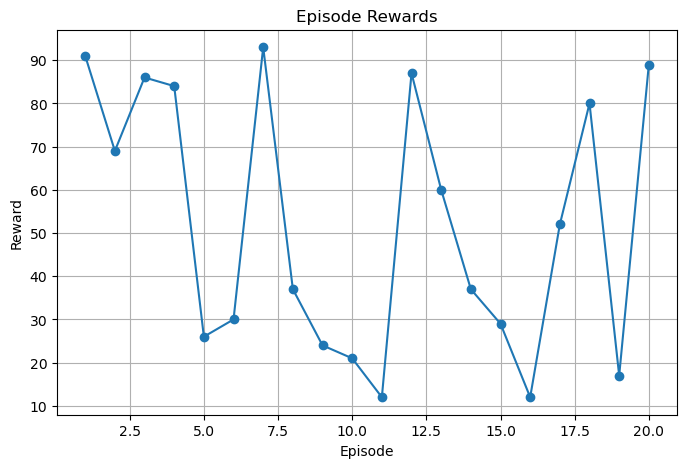

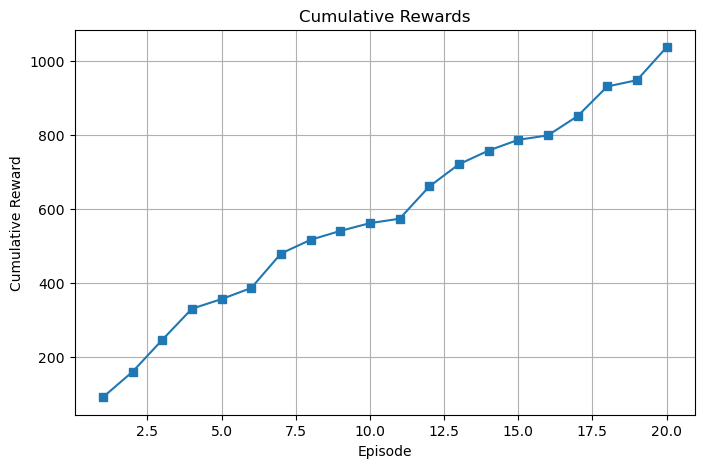

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Number of episodes
episodes = 20

# Simulated rewards
episode_rewards = np.random.randint(10, 101, size=episodes)

# Calculate cumulative rewards
cumulative_rewards = np.cumsum(episode_rewards)

print("Episode Rewards:")
print(episode_rewards)

print("\nCumulative Rewards:")
print(cumulative_rewards)

# Plot Episode Rewards
plt.figure(figsize=(8,5))
plt.plot(range(1, episodes + 1), episode_rewards, marker='o')
plt.title("Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# Plot Cumulative Rewards
plt.figure(figsize=(8,5))
plt.plot(range(1, episodes + 1), cumulative_rewards, marker='s')
plt.title("Cumulative Rewards")
plt.xlabel("Episode")
plt.ylabel("Cumulative Reward")
plt.grid(True)
plt.show()

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# Create Neural Network
model = Sequential([
    Dense(24, activation='relu', input_shape=(4,)),
    Dense(24, activation='relu'),
    Dense(2, activation='linear')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['accuracy']
)

# Display model summary
print("Neural Network Summary:")
model.summary()

# Sample input (dummy state)
sample_state = np.array([[0.1, 0.2, 0.3, 0.4]])

# Predict output
prediction = model.predict(sample_state)

print("\nPredicted Q-Values:")
print(prediction)

Neural Network Summary:


C:\Users\VARSHINI\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 24)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │           600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            50 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 770 (3.01 KB)

 Trainable params: 770 (3.01 KB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step

Predicted Q-Values:
[[0.03398605 0.24507196]]


In [10]:
import gymnasium as gym
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Create CartPole Environment
env = gym.make("CartPole-v1")

# Build Neural Network
model = Sequential([
    Dense(24, activation="relu", input_shape=(4,)),
    Dense(24, activation="relu"),
    Dense(2, activation="linear")
])

model.compile(optimizer="adam", loss="mse")

episodes = 5
total_rewards = []

for episode in range(episodes):

    state, info = env.reset()
    done = False
    reward_sum = 0

    while not done:

        # Random action (basic agent)
        action = env.action_space.sample()

        next_state, reward, terminated, truncated, info = env.step(action)

        reward_sum += reward

        state = next_state

        done = terminated or truncated

    total_rewards.append(reward_sum)

    print(f"Episode {episode+1}: Reward = {reward_sum}")

env.close()

average_reward = np.mean(total_rewards)

print("\nAverage Reward:", average_reward)

success_rate = (sum(r >= 20 for r in total_rewards) / episodes) * 100

print("Success Rate:", success_rate, "%")

Episode 1: Reward = 28.0
Episode 2: Reward = 16.0
Episode 3: Reward = 29.0
Episode 4: Reward = 30.0
Episode 5: Reward = 21.0

Average Reward: 24.8
Success Rate: 80.0 %
